In [1]:
#Import the required libraries
import numpy as np
import json
import tensorflow as tf

from pathlib import Path

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import(
    Embedding,
    SimpleRNN,
    Dense
)

In [2]:
#Load training and validation data
processed_dir = Path("../data/processed")


# Load the 20-word input sequences.
X_train = np.load(
    processed_dir / "X_train.npy"
)


# Load the correct next words.
Y_train = np.load(
    processed_dir / "Y_train.npy"
)


# Load validation data.
X_val = np.load(
    processed_dir / "X_val.npy"
)

Y_val = np.load(
    processed_dir / "Y_val.npy"
)


print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

X_train: (2153888, 20)
Y_train: (2153888,)
X_val: (237549, 20)
Y_val: (237549,)


In [3]:
#load preprocessing configuration
with open(
    processed_dir / "config.json",
    "r"
) as file:

    config = json.load(file)

VOCAB_SIZE = config["vocab_size"]

CONTEXT_LENGTH = config["context_length"]

print("vocabulary size:", VOCAB_SIZE)
print("context length:", CONTEXT_LENGTH)

vocabulary size: 20000
context length: 20


In [19]:
#Build simple rnn model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense
EMBEDDING_DIM = 128

RNN_UNITS = 128

model = Sequential([
    Input(shape=(CONTEXT_LENGTH,)),
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),
    SimpleRNN(
        RNN_UNITS,
        return_sequences=False,
        unroll=True
    ),
    Dense(
        VOCAB_SIZE,
        activation="softmax"
    )
])

In [20]:
#Compile Model
model.compile(
    #Adam adjusts the neural-network weights during training
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=[
        "sparse_categorical_accuracy"
    ]
)

In [13]:
#SMALL training test
TEST_SIZE = 100000


history_test = model.fit(

    X_train[:TEST_SIZE],
    Y_train[:TEST_SIZE],

    # Number of examples processed simultaneously.
    batch_size=256,

    # Only two epochs because this is a test.
    epochs=2,

    # Use some validation examples.
    validation_data=(
        X_val[:20000],
        Y_val[:20000]
    )

)

Epoch 1/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - loss: 7.3551 - sparse_categorical_accuracy: 0.0529 - val_loss: 7.0786 - val_sparse_categorical_accuracy: 0.0690
Epoch 2/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - loss: 6.6909 - sparse_categorical_accuracy: 0.0840 - val_loss: 6.8438 - val_sparse_categorical_accuracy: 0.1043


In [21]:
#Create a fresh RNN for full training
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

EMBEDDING_DIM = 128

RNN_UNITS = 128

rnn_model = Sequential([
    Input(shape=(CONTEXT_LENGTH,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),

    Dense(
        VOCAB_SIZE,
        activation="softmax"
        )
])
print("new RNN created")


new RNN created


In [33]:
#Compile the final RNN
import tensorflow as tf

rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",

    metrics=[
        #top-1 accuracy 
        # is the models single most likely word exactly the correct nexrt word
        tf.keras.metrics.SparseCategoricalAccuracy(
            name="accuracy"
        ),
        #TOP-5 accuracy
        #is the correct word somewhere 
        #among the models five most likely predictions?
        tf.keras.metrics.SparseTopKCategoricalAccuracy(
            k=5,
            name="top_5_accuracy"
        )
    ],
    jit_compile=False
)
print("RNN completed successfully")

rnn_model.summary()

RNN completed successfully


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20000)          │     2,580,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,172,896 (19.73 MB)

 Trainable params: 5,172,896 (19.73 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
#Training callbacks
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from pathlib import Path

# Directory where trained models will be stored
model_dir = Path("../models")

# Create the directory if it does not already exist
model_dir.mkdir(exist_ok=True)
# If validation loss stops improving for 2 consecutive epochs,
# stop training.
#
# restore_best_weights=True means:
# after training, use the weights from the best epoch,
# not necessarily the final epoch.
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)
# Save the model whenever validation loss reaches
# a new best value.
checkpoint = ModelCheckpoint(
    model_dir / "best_rnn.keras",
    monitor="val_loss",
    save_best_only=True
)
# If validation loss stops improving,
# reduce the learning rate.
#
# This lets the model make smaller adjustments
# when it gets closer to a good solution.
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6
)

In [24]:
# ============================================================
# RESET KERAS
# ============================================================

import tensorflow as tf

# Clears old models/layers stored in the current Keras session.
# This helps avoid accidentally continuing with an older model.
tf.keras.backend.clear_session()

print("Keras session cleared.")

Keras session cleared.


In [29]:
# ============================================================
# CREATE THE CORRECT SIMPLE RNN MODEL
# ============================================================

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense


# Clear any previously created models from the Keras session
tf.keras.backend.clear_session()


# Number of values used to represent each word
EMBEDDING_DIM = 128

# Number of hidden units in the RNN
RNN_UNITS = 128


# Build the model
rnn_model = Sequential([

    # --------------------------------------------------------
    # INPUT
    # --------------------------------------------------------
    # Each training example contains 20 previous words
    #
    # Shape:
    # (batch_size, 20)
    Input(shape=(CONTEXT_LENGTH,)),


    # --------------------------------------------------------
    # EMBEDDING
    # --------------------------------------------------------
    # Converts each word ID into a 128-dimensional vector
    #
    # Input:
    # (batch_size, 20)
    #
    # Output:
    # (batch_size, 20, 128)
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    ),


    # --------------------------------------------------------
    # SIMPLE RNN
    # --------------------------------------------------------
    # This is the layer you were missing.
    #
    # It reads the 20 word vectors one by one and keeps
    # information from previous words in its hidden state.
    #
    # return_sequences=False means:
    # only return ONE final representation after reading
    # all 20 words.
    #
    # Output:
    # (batch_size, 128)
    SimpleRNN(
        units=RNN_UNITS,
        return_sequences=False,
        unroll=True
    ),


    # --------------------------------------------------------
    # OUTPUT LAYER
    # --------------------------------------------------------
    # Predict probability for each possible next word.
    #
    # Vocabulary size = 20,000
    #
    # Output:
    # (batch_size, 20000)
    Dense(
        VOCAB_SIZE,
        activation="softmax"
    )

])


print("Correct Simple RNN model created.")

Correct Simple RNN model created.


In [32]:
rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20000)          │     2,580,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,172,896 (19.73 MB)

 Trainable params: 5,172,896 (19.73 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
#train sample on full dataset
history_rnn = rnn_model.fit(

    # Full training dataset
    X_train,
    Y_train,

    # Process 256 sequences at a time
    batch_size=256,

    # Maximum number of passes through the full dataset.
    #
    # EarlyStopping may stop us before reaching epoch 10.
    epochs=10,

    # Full validation dataset
    validation_data=(
        X_val,
        Y_val
    ),

    # Automatic training controls
    callbacks=[
        early_stopping,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/10
8414/8414 ━━━━━━━━━━━━━━━━━━━━ 345s 41ms/step - accuracy: 0.1655 - loss: 5.8542 - top_5_accuracy: 0.3076 - val_accuracy: 0.1994 - val_loss: 5.3332 - val_top_5_accuracy: 0.3596 - learning_rate: 0.0010
Epoch 2/10
8414/8414 ━━━━━━━━━━━━━━━━━━━━ 553s 66ms/step - accuracy: 0.2162 - loss: 5.0644 - top_5_accuracy: 0.3828 - val_accuracy: 0.2171 - val_loss: 5.0752 - val_top_5_accuracy: 0.3870 - learning_rate: 0.0010
Epoch 3/10
8414/8414 ━━━━━━━━━━━━━━━━━━━━ 2344s 279ms/step - accuracy: 0.2345 - loss: 4.7592 - top_5_accuracy: 0.4119 - val_accuracy: 0.2247 - val_loss: 4.9733 - val_top_5_accuracy: 0.3975 - learning_rate: 0.0010
Epoch 4/10
8414/8414 ━━━━━━━━━━━━━━━━━━━━ 7276s 865ms/step - accuracy: 0.2484 - loss: 4.5556 - top_5_accuracy: 0.4320 - val_accuracy: 0.2290 - val_loss: 4.9347 - val_top_5_accuracy: 0.4038 - learning_rate: 0.0010
Epoch 5/10
8414/8414 ━━━━━━━━━━━━━━━━━━━━ 280s 33ms/step - accuracy: 0.2595 - loss: 4.4024 - top_5_accuracy: 0.4482 - val_accuracy: 0.2316 - val_loss: 4

In [35]:
# ============================================================
# SAVE RNN TRAINING HISTORY
# ============================================================

import pandas as pd
from pathlib import Path

results_dir = Path("../results")
results_dir.mkdir(exist_ok=True)

# history_rnn.history contains the metrics from every epoch
history_df = pd.DataFrame(history_rnn.history)

# Save them so we can later compare RNN vs LSTM
history_df.to_csv(
    results_dir / "rnn_training_history.csv",
    index=False
)

print(history_df)
print("\nRNN training history saved.")

   accuracy      loss  top_5_accuracy  val_accuracy  val_loss  \
0  0.165516  5.854183        0.307630      0.199403  5.333225   
1  0.216151  5.064353        0.382800      0.217100  5.075179   
2  0.234548  4.759236        0.411893      0.224712  4.973322   
3  0.248362  4.555635        0.432009      0.228972  4.934715   
4  0.259477  4.402419        0.448172      0.231607  4.907017   
5  0.269745  4.281671        0.461779      0.234722  4.906312   
6  0.278426  4.184887        0.472921      0.235404  4.913383   
7  0.299672  3.969251        0.499272      0.241752  4.860968   
8  0.307517  3.902904        0.508102      0.242927  4.867326   
9  0.322020  3.777337        0.524661      0.245267  4.856741   

   val_top_5_accuracy  learning_rate  
0            0.359631        0.00100  
1            0.387015        0.00100  
2            0.397505        0.00100  
3            0.403761        0.00100  
4            0.408324        0.00100  
5            0.409414        0.00100  
6          

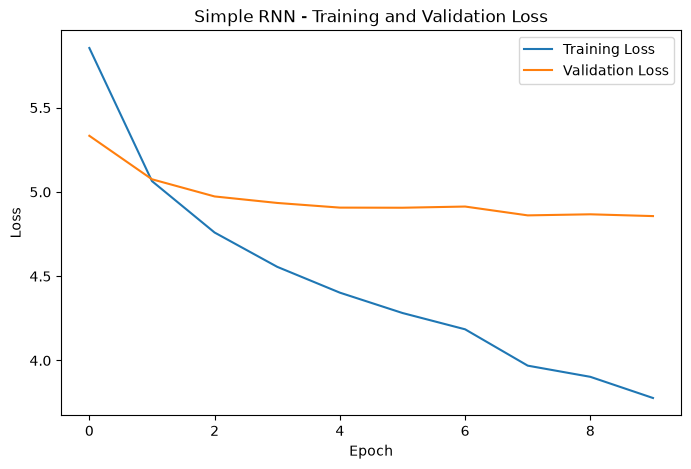

In [36]:
#Create graphs
import matplotlib.pyplot as plt

# Training vs validation loss
plt.figure(figsize=(8, 5))

plt.plot(
    history_rnn.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_rnn.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Simple RNN - Training and Validation Loss")
plt.legend()
plt.show()

In [41]:
# ============================================================
# LOAD TOKENIZER
# ============================================================

import pickle
from pathlib import Path

# Your actual file is currently named "tokennizer.pkl"
tokenizer_path = Path("../data/processed/tokennizer.pkl")

# Check first
print("Tokenizer exists:", tokenizer_path.exists())

# Load it
with open(tokenizer_path, "rb") as file:
    tokenizer = pickle.load(file)

print("Tokenizer loaded successfully.")

Tokenizer exists: True
Tokenizer loaded successfully.


In [43]:
# ============================================================
# CREATE REVERSE WORD LOOKUP
# ============================================================

# tokenizer.word_index stores:
# word -> integer
#
# Example:
# "patient" -> 52
#
# For predictions, we need the reverse:
# integer -> word

index_to_word = {
    index: word
    for word, index in tokenizer.word_index.items()
}

print("Reverse vocabulary created.")
print("Number of words:", len(index_to_word))

Reverse vocabulary created.
Number of words: 38626


In [44]:
# ============================================================
# SHOW ONE SAMPLE PREDICTION FROM THE TRAINED RNN
# ============================================================

import numpy as np


# Pick one validation example
# You can change 100 to 500, 1000, etc.
example_number = 100


# ------------------------------------------------------------
# GET THE INPUT AND ACTUAL NEXT WORD
# ------------------------------------------------------------

# X_val contains the 20-word input sequence
sample_input = X_val[example_number]

# Y_val contains the correct next word ID
actual_word_id = Y_val[example_number]


# ------------------------------------------------------------
# CONVERT INPUT WORD IDS BACK TO TEXT
# ------------------------------------------------------------

input_words = [
    index_to_word.get(int(word_id), "<OOV>")
    for word_id in sample_input
]

print("INPUT TEXT:")
print(" ".join(input_words))


# Convert the correct target ID back to a word
actual_word = index_to_word.get(
    int(actual_word_id),
    "<OOV>"
)

print("\nACTUAL NEXT WORD:")
print(actual_word)


# ------------------------------------------------------------
# PREPARE INPUT FOR THE RNN
# ------------------------------------------------------------

# sample_input shape is:
# (20,)
#
# The model expects:
# (batch_size, 20)
#
# So we convert it into:
# (1, 20)

model_input = np.expand_dims(
    sample_input,
    axis=0
)


# ------------------------------------------------------------
# MAKE THE PREDICTION
# ------------------------------------------------------------

# The model returns probabilities for all 20,000 words.
#
# Shape returned:
# (1, 20000)
#
# [0] removes the batch dimension,
# leaving just the 20,000 probabilities.

predictions = rnn_model.predict(
    model_input,
    verbose=0
)[0]


# ------------------------------------------------------------
# GET THE TOP 5 MOST LIKELY WORDS
# ------------------------------------------------------------

# np.argsort gives the word IDs ordered by probability.
#
# [-5:] gets the five highest.
# [::-1] reverses them so the highest is first.

top_5_ids = np.argsort(predictions)[-5:][::-1]


print("\nTOP 5 RNN PREDICTIONS:")

for rank, word_id in enumerate(top_5_ids, start=1):

    predicted_word = index_to_word.get(
        int(word_id),
        "<OOV>"
    )

    probability = predictions[word_id]

    print(
        f"{rank}. {predicted_word} "
        f"- {probability * 100:.2f}%"
    )


# ------------------------------------------------------------
# CHECK WHETHER THE RNN GOT IT RIGHT
# ------------------------------------------------------------

top_1_id = top_5_ids[0]

if top_1_id == actual_word_id:

    print("\n✅ Correct! The RNN predicted the actual word as #1.")

elif actual_word_id in top_5_ids:

    print("\n✅ The actual word appeared in the Top-5 predictions.")

else:

    print("\n❌ The actual word was not in the Top-5 predictions.")
    

INPUT TEXT:
and 1 2 degrees 29 in lateral bending the most restricted motion governed by the iliolumbar ligament in the lumbosacral

ACTUAL NEXT WORD:
junction

TOP 5 RNN PREDICTIONS:
1. area - 16.34%
2. discs - 9.80%
3. <OOV - 7.39%
4. disc - 5.19%
5. junction - 4.24%

✅ The actual word appeared in the Top-5 predictions.
